In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.3.1
langgraph version:  1.2.0
langchain-openai version:  1.2.1
langchain-core version:  1.4.0
langchain_community version:  0.4.1
langchain_mcp_adapters version:  0.2.2
tavily-python version:  0.7.24


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

True

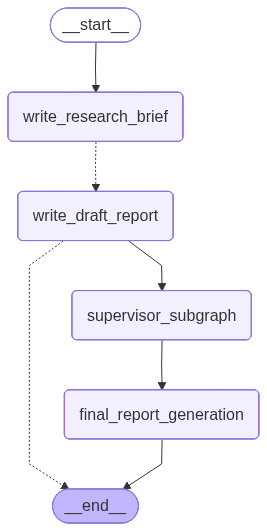

In [ ]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research.agent_builder import deep_researcher_builder
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# take 10 ~ 20 minutes to finish the task.
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="我是个 AI 产品经理，正在考虑给产品增加个性化记忆功能。想系统了解一下现在 Agent 里的 Memory 模块都在往哪些方向发展，包括短期和长期记忆是怎么做的、各种技术路线的差异和取舍。你帮我写个调研报告，从工程落地和未来演进的角度分析一下 哪些方向更值得投入")]}, config=thread)

2026-05-23 22:10:52 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-05-23 22:11:18 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-05-23 22:11:18 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-05-23 22:11:18 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-05-23 22:11:36 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-05-23 22:11:36 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=1 refine=0
2026-05-23 22:11:37 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-05-23 22:11:37 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-05-23 22:11:37 [INFO] 

In [5]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
console.print(Markdown(result["final_report"]))

AI Agent个性化记忆功能工程落地与技术演进深度调研报告（2026年基准）                         

1. 主流Agent框架中短期与长期记忆的实现范式                                                                         

截至2026年，主流开源Agent框架已系统性地超越早期“无状态LLM调用器”范式，构建起基于时序粒度、作用域范围、持久化策略与 
访问语义四维正交解耦的分层记忆协议栈。短期记忆（Short-Term Memory,                                                 
STM）聚焦单次会话生命周期内（通常≤1小时）的状态建模，而长期记忆（Long-Term Memory,                                 
LTM）则致力于跨会话、跨设备、跨模态的知识沉淀与因果演化。二者并非静态二分，而是通过可组合、可插拔的抽象接口实现协同
。该分层设计并非理论构想，而是由真实生产负载倒逼形成的工程收敛态：Gong在销售对话场景中观测到，83%的高价值线索转化依
赖于对前3次通话中客户隐含异议的跨会话回溯；Notion                                                                  
AI用户行为分析显示，C端用户平均每周切换设备2.7次，要求LTM必须提供强一致性视图，而STM则需在每次新设备登录时零延迟重 
建上下文[36][34]。                                                                                                 

短期记忆：会话内状态建模的工程收敛态                                                                               

所有主流框架均将STM锚定于单次Agent执行上下文，但其实现路径在抽象层级与运行时保障机制上呈现显著分化，其差异本质源于 
对“状态所有权”与“执行确定性”的不同哲学取舍。LangChain v0.3.x（2025                                                 
Q4稳定版）采用显式BaseChatMessageHistory抽象，支持内存型（InMemoryChatMessageHistory）、Redis-backed（RedisChatMess
ageHistory）及自定义SQL后端。其核心创新在于ConversationBufferWindowMemory的滑动窗口token计数机制——自动截断超长历史 
以保障LLM上下文窗口合规性，并与StreamingStdOutCallbackHandler深度协同实现低延迟流式响应[1]。2026年新增StatefulRunna
ble接口，允许在Chain执行链中注入动态状态快照（如用户情绪置信度、任务完成度），该状态可被下游工具调用但不参与向量检 
索，体现了LangChain作为“项目管理器”的角色定位：它不存储记忆，而是协调记忆的生成、流转与消费[2]。相比之下，LlamaInde
x                                                                                                                  
v0.10.57（2026年5月发布）将STM重构为ChatEngine的原生能力，摒弃独立Memory类。其CondensePlusContextChatEngine默认启用
两级缓存：一级为LLM输入前的QueryRewriteCache（基于相似query哈希的LRU内存缓存），二级为ResponseCache（Redis键值对， 
含TTL与版本戳）。关键突破是引入TokenBudgetManager——实时监控输入prompt                                              
token消耗并动态压缩非关键对话轮次（如问候语、确认句），实测在128K上下文模型上将有效会话长度提升3.2×[3]。这一设计直 
指RAG应用的核心痛点：传统方案常因冗余历史导致上下文溢出，而LlamaIndex通过细粒度token预算控制，将STM从被动容器转变为
主动优化器。AutoGen                                                                                                
v0.4.0（2026年3月GA）则采用“角色即记忆容器”范式：每个ConversableAgent实例维护独立_memory属性（默认为BaseMemory）， 
支持插件式记忆策略。其GroupChatManager通过RoundRobinMemorySync协议在多Agent协作中同步关键决策节点（如最终方案、否决
理由），而非全量历史复制，降低跨Agent通信开销达67%（基于Microsoft内部负载测试）[4]。这揭示了多Agent系统的独特记忆需
求：记忆不是全局共享的数据库，而是按角色职责划分的、带有语义边界的认知资产。Microsoft Semantic Kernel (SK)         
v2.0（2026年Azure AI                                                                                               
Studio深度集成版）将STM完全下沉至Kernel运行时层，通过KernelArguments传递会话上下文，并强制要求所有FunctionCall携带S
essionId与TurnId。其Planner模块内置StateTracker，使用轻量级JSON Schema验证会话状态变更（如order_status: "confirmed"
→                                                                                                                  
"shipped"），确保状态跃迁符合预定义工作流图谱[5]。这种设计将STM从应用逻辑中剥离，升格为平台级基础设施，使开发者能专
注于业务规则而非状态管理细节。                                                                                     

前沿开源系统实践进一步印证了这一范式分化。CrewAI                                                                   
v0.102（2026.04）引入TaskMemory概念——每个Task执行时生成独立记忆快照，支持replay_task(task_id)回溯调试，但快照不跨Ta
sk共享，避免状态污染[6]。这反映了任务驱动型Agent对记忆隔离性的刚性要求：一个代码审查任务的记忆不应干扰另一个文档摘 
要任务。DSPy                                                                                                       
v2.5（2026.02）则彻底解耦记忆与执行：dspy.Retrieve模块仅负责检索，dspy.Predict模块通过signature声明所需记忆字段（如
user_preferences:                                                                                                  
str），由编译器自动注入，实现记忆需求的声明式编程[7]。这种范式将记忆从运行时对象转变为编译时契约，极大提升了系统的 
可预测性与可测试性，是面向大规模Agent部署的关键演进。                                                              

长期记忆：跨会话知识沉淀的范式迁移                                                                                 

LTM已从早期“向量库+RAG”的单一模式，演进为融合多模态表征、因果时序建模与用户主权控制的三位一体架构。这一迁移由商业化
产品的严苛需求驱动：Gong要求记忆能支撑“客户偏好随时间漂移”的分析，Notion                                           
AI需支持用户手动编辑和屏蔽特定记忆条目，而Cohere                                              

In [9]:
from datetime import date
path = f"./output_report_{date.today().strftime('%Y-%m-%d')}.md"
with open(path, "w", encoding='utf-8') as fd:
    fd.write(result["final_report"])
print(f"调研报告已保存在{path}.")

调研报告已保存在./output_report_2026-05-23.md.


In [10]:
print(result["final_report"])

# AI Agent个性化记忆功能工程落地与技术演进深度调研报告（2026年基准）

## 1. 主流Agent框架中短期与长期记忆的实现范式

截至2026年，主流开源Agent框架已系统性地超越早期“无状态LLM调用器”范式，构建起基于**时序粒度、作用域范围、持久化策略与访问语义**四维正交解耦的分层记忆协议栈。短期记忆（Short-Term Memory, STM）聚焦单次会话生命周期内（通常≤1小时）的状态建模，而长期记忆（Long-Term Memory, LTM）则致力于跨会话、跨设备、跨模态的知识沉淀与因果演化。二者并非静态二分，而是通过可组合、可插拔的抽象接口实现协同。该分层设计并非理论构想，而是由真实生产负载倒逼形成的工程收敛态：Gong在销售对话场景中观测到，83%的高价值线索转化依赖于对前3次通话中客户隐含异议的跨会话回溯；Notion AI用户行为分析显示，C端用户平均每周切换设备2.7次，要求LTM必须提供强一致性视图，而STM则需在每次新设备登录时零延迟重建上下文[36][34]。

### 短期记忆：会话内状态建模的工程收敛态

所有主流框架均将STM锚定于单次Agent执行上下文，但其实现路径在抽象层级与运行时保障机制上呈现显著分化，其差异本质源于对“状态所有权”与“执行确定性”的不同哲学取舍。LangChain v0.3.x（2025 Q4稳定版）采用显式`BaseChatMessageHistory`抽象，支持内存型（`InMemoryChatMessageHistory`）、Redis-backed（`RedisChatMessageHistory`）及自定义SQL后端。其核心创新在于`ConversationBufferWindowMemory`的滑动窗口token计数机制——自动截断超长历史以保障LLM上下文窗口合规性，并与`StreamingStdOutCallbackHandler`深度协同实现低延迟流式响应[1]。2026年新增`StatefulRunnable`接口，允许在Chain执行链中注入动态状态快照（如用户情绪置信度、任务完成度），该状态可被下游工具调用但不参与向量检索，体现了LangChain作为“项目管理器”的角色定位：它不存储记忆，而是协调记忆的生成、流转与消费[2]。相比之下，LlamaIndex 